In [1]:
pip install scikit-learn xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 837.5 kB/s eta 0:02:01
   ---------------------------------------- 0.5/101.7 MB 837.5 kB/s eta 0:02:01
   ---------------------------------------- 1.0/101.7 MB 1.0 MB/s eta 0:01:40
   ---------------------------------------- 1.0/101.7 MB 1.0 MB/s eta 0:01:40
    --------------------------------------- 1.3/101.7 MB 894.7 kB/s eta 0:01:53
    --------------------------------------- 1.6/101.7 MB 953.2 kB/s eta 0:01:46
    --------------------------------------- 1.6/101.7 MB 953.2 kB/s eta 0:01:46
    --------------------------------------- 1.8/101.7 MB 906.5 kB/s eta 0:01:51
    --------------------------------------- 2.1/101.7 MB 931.9 kB/s eta 0:01:47
    --------------------------------------- 2.1/101.7 MB 931.9 kB/s eta

ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\anjan\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "c:\Users\anjan\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\anjan\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\anjan\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\anjan\anaconda3\Lib\http\client.py", line 479, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "c:\Users\anjan\anaconda3\Lib\socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✔ Library ML siap!")

✔ Library ML siap!


In [3]:
df = pd.read_csv("df_final_panel.csv")

# Hapus missing values
df = df.dropna()

print(f"Shape data: {df.shape}")
print(f"\nInfo data:")
print(df.info())
print(f"\n5 baris pertama:")
print(df.head())

Shape data: (175, 6)

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   kabupaten_kota  175 non-null    object 
 1   tahun           175 non-null    int64  
 2   kemiskinan_pct  175 non-null    float64
 3   ipm             175 non-null    float64
 4   tpt             175 non-null    float64
 5   pdrb            175 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 8.3+ KB
None

5 baris pertama:
           kabupaten_kota  tahun  kemiskinan_pct    ipm   tpt   pdrb
0  3301 KABUPATEN CILACAP   2020           11.46  69.95  9.10 -10.28
1  3301 KABUPATEN CILACAP   2021           11.67  70.42  9.97   2.15
2  3301 KABUPATEN CILACAP   2022           11.02  70.99  9.62   5.15
3  3301 KABUPATEN CILACAP   2023           10.99  71.83  8.74   5.32
4  3301 KABUPATEN CILACAP   2024           10.68  72.38  7.83   2.70


In [4]:
# Variabel X (fitur) dan Y (target)
X = df[["ipm", "tpt", "pdrb"]]
y = df["kemiskinan_pct"]

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standarisasi fitur
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Data train : {X_train.shape}")
print(f"Data test  : {X_test.shape}")
print("✔ Data siap untuk modeling!")

Data train : (140, 3)
Data test  : (35, 3)
✔ Data siap untuk modeling!


In [5]:
# Train model
lr = LinearRegression()
lr.fit(X_train_s, y_train)

# Prediksi
y_pred_lr = lr.predict(X_test_s)

# Evaluasi
r2_lr  = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("===== LINEAR REGRESSION =====")
print(f"R² Score : {r2_lr:.4f}")
print(f"MSE      : {mse_lr:.4f}")
print(f"MAE      : {mae_lr:.4f}")
print(f"\nKoefisien:")
for feat, coef in zip(X.columns, lr.coef_):
    print(f"  {feat}: {coef:.4f}")

===== LINEAR REGRESSION =====
R² Score : 0.4172
MSE      : 7.1727
MAE      : 2.2569

Koefisien:
  ipm: -2.4142
  tpt: -0.0324
  pdrb: 0.4121


In [6]:
# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test_s)

# Evaluasi
r2_rf  = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("===== RANDOM FOREST =====")
print(f"R² Score : {r2_rf:.4f}")
print(f"MSE      : {mse_rf:.4f}")
print(f"MAE      : {mae_rf:.4f}")

===== RANDOM FOREST =====
R² Score : 0.5300
MSE      : 5.7842
MAE      : 1.9713


In [7]:
hasil = pd.DataFrame({
    "Model"   : ["Linear Regression", "Random Forest"],
    "R² Score": [round(r2_lr, 4),  round(r2_rf, 4)],
    "MSE"     : [round(mse_lr, 4), round(mse_rf, 4)],
    "MAE"     : [round(mae_lr, 4), round(mae_rf, 4)]
})

print("===== PERBANDINGAN MODEL =====")
print(hasil.to_string(index=False))

# Model terbaik
best = hasil.loc[hasil["R² Score"].idxmax(), "Model"]
print(f"\n✔ Model terbaik: {best}")

===== PERBANDINGAN MODEL =====
            Model  R² Score    MSE    MAE
Linear Regression    0.4172 7.1727 2.2569
    Random Forest    0.5300 5.7842 1.9713

✔ Model terbaik: Random Forest


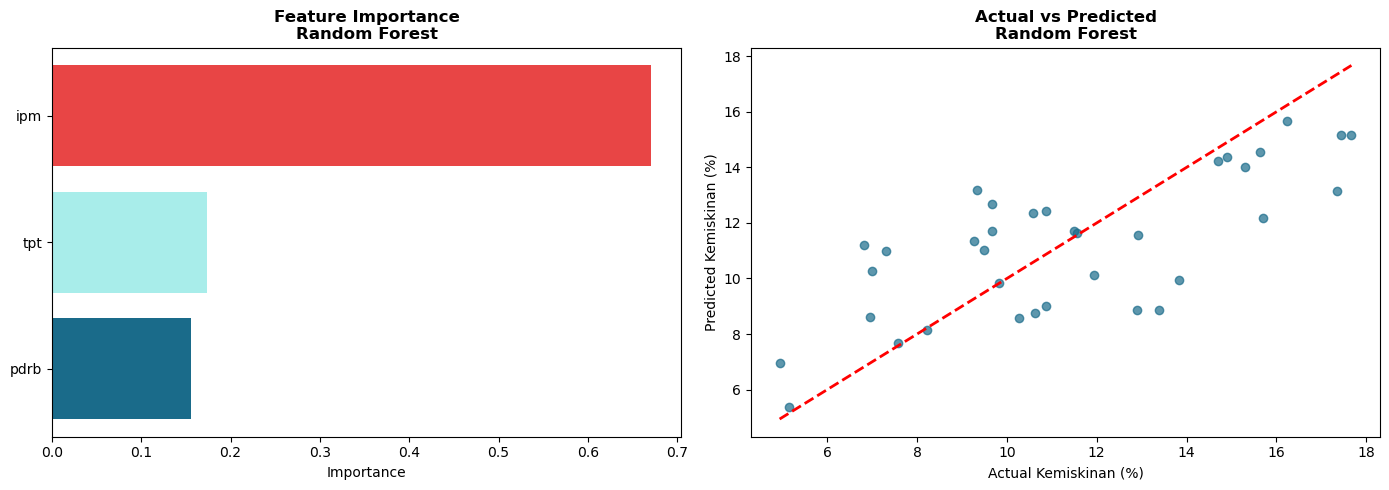

✔ Plot tersimpan!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance Random Forest
importance = pd.DataFrame({
    "Fitur"      : X.columns,
    "Importance" : rf.feature_importances_
}).sort_values("Importance", ascending=True)

axes[0].barh(importance["Fitur"], importance["Importance"],
             color=["#1a6b8a", "#a8edea", "#e84545"])
axes[0].set_title("Feature Importance\nRandom Forest",
                  fontweight="bold")
axes[0].set_xlabel("Importance")

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_rf, alpha=0.7, color="#1a6b8a")
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--", linewidth=2)
axes[1].set_xlabel("Actual Kemiskinan (%)")
axes[1].set_ylabel("Predicted Kemiskinan (%)")
axes[1].set_title("Actual vs Predicted\nRandom Forest",
                  fontweight="bold")

plt.tight_layout()
plt.savefig("plot_ml_hasil.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot tersimpan!")

In [9]:
# Cross validation 5-fold
cv_lr = cross_val_score(lr, X_train_s, y_train, cv=5, scoring="r2")
cv_rf = cross_val_score(rf, X_train_s, y_train, cv=5, scoring="r2")

print("===== CROSS VALIDATION (5-Fold) =====")
print(f"Linear Regression : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"Random Forest     : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

===== CROSS VALIDATION (5-Fold) =====
Linear Regression : 0.4339 ± 0.1091
Random Forest     : 0.3625 ± 0.1535


In [10]:
print("=" * 50)
print("RINGKASAN PROJECT 4 - MACHINE LEARNING")
print("=" * 50)
print(f"\nTarget variabel  : Kemiskinan (%)")
print(f"Fitur            : IPM, TPT, PDRB")
print(f"Data train       : {len(X_train)} observasi")
print(f"Data test        : {len(X_test)} observasi")
print(f"\n--- Hasil Model ---")
print(f"Linear Regression R² : {r2_lr:.4f}")
print(f"Random Forest R²     : {r2_rf:.4f}")
print(f"\n✔ Model terbaik  : {best}")
print("\n✔ Project 4 Selesai!")    

RINGKASAN PROJECT 4 - MACHINE LEARNING

Target variabel  : Kemiskinan (%)
Fitur            : IPM, TPT, PDRB
Data train       : 140 observasi
Data test        : 35 observasi

--- Hasil Model ---
Linear Regression R² : 0.4172
Random Forest R²     : 0.5300

✔ Model terbaik  : Random Forest

✔ Project 4 Selesai!
